<a href="https://colab.research.google.com/github/ma-stanford/cs230-project-clincalmindai/blob/main/CS230_Project_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This notebook implements a Deep Knowledge Tracing (DKT) system for predicting medical student performance on clinical reasoning assessments. We compare two approaches:

1. **MLP with Aggregate Features** - A feedforward network using 26 engineered features
2. **LSTM-DKT** - A sequential model learning temporal patterns from interaction sequences
---

## Table of Contents

1. Setup & Configuration
2. Data Loading
3. Preprocessing & Sequence Generation
4. Baseline: MLP with Aggregate Features
5. LSTM-DKT Model
6. Results & Analysis

## 1. Setup & Imports

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict

from google.cloud import bigquery
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm

# Reproducibility
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

Using device: cuda


## 2. Data Loading

Student performance data is retrieved from BigQuery. The dataset contains interaction records from medical students completing clinical case simulations at Universidad de Chile Medical School.

In [ ]:
# Connect to BigQuery and load performance data
client = bigquery.Client(project='gcp-dev-sandbox')

query = """
SELECT
    attemptId,
    responseById,
    questionPosition,
    achievedScore,
    maxScore,
    questionType,
    rubricId,
    rubricTitle,
    question,
    case_number
FROM `gcp-dev-sandbox.clinical_mind_ai.performance`
WHERE achievedScore IS NOT NULL
ORDER BY attemptId, questionPosition
"""

all_perf = client.query(query).to_dataframe()

print(f"Loaded {len(all_perf):,} records")
print(f"Students: {all_perf['responseById'].nunique()}")
print(f"Attempts: {all_perf['attemptId'].nunique()}")
print(f"Cases: {sorted(all_perf['case_number'].unique())}")

RefreshError: ("Failed to retrieve http://metadata.google.internal/computeMetadata/v1/instance/service-accounts/default/?recursive=true from the Google Compute Engine metadata service. Status: 404 Response:\nb''", <google.auth.transport.requests._Response object at 0x7fc1b1c82ff0>)

### 2.1 Behavioral Features

We incorporate two behavioral features that capture student engagement patterns:
- **Clinical reasoning score**: Ratio of relevant to irrelevant physical exam actions
- **Inter-attempt interval**: Time between attempts, which may indicate knowledge retention

In [ ]:
# Load pre-computed behavioral features
try:
    fishing_lookup = np.load('/tmp/fishing_lookup.npy', allow_pickle=True).item()
except FileNotFoundError:
    fishing_lookup = {}

try:
    lag_lookup = np.load('/tmp/lag_lookup.npy', allow_pickle=True).item()
except FileNotFoundError:
    lag_lookup = {}
    for attempt_id in all_perf['attemptId'].unique():
        lag_lookup[attempt_id] = {'log_inter_attempt_lag': 10.0, 'is_first_attempt': 1.0}

print(f"Clinical reasoning scores: {len(fishing_lookup)} attempts")
print(f"Inter-attempt intervals: {len(lag_lookup)} attempts")

Clinical reasoning scores: 0 attempts
Inter-attempt intervals: 1522 attempts


## 3. Data Preprocessing

Raw performance records are converted into prediction sequences using a sliding window approach. Each sequence contains a student's response history, and the target is their score on the subsequent question.

In [ ]:
# Preprocessing
all_perf.rename(columns={'case_number': 'case'}, inplace=True)

# Handle missing values
all_perf['questionPosition'] = all_perf['questionPosition'].fillna(0)
all_perf['achievedScore'] = all_perf['achievedScore'].fillna(0.0)
all_perf['maxScore'] = all_perf['maxScore'].fillna(0.0)
all_perf['case'] = all_perf['case'].fillna(0)

# Normalize scores to [0, 1] using actual maxScore
# Score normalization: maxScore varies by question type (4, 6, or 8)
def normalize_score(row):
    achieved = row['achievedScore']
    max_score = row['maxScore']

    if pd.notna(max_score) and max_score > 0:
        return achieved / max_score

    # Fallback based on question type when maxScore is missing
    q_type = row['questionType']
    if q_type in ['MCQ', 'CLICK_IN_PICTURE']:
        return achieved / 4.0
    elif q_type == 'MEDICAL_HISTORY':
        return achieved / 8.0
    elif q_type == 'OPEN_ENDED':
        return achieved / 8.0 if achieved > 4 else achieved / 4.0
    else:
        return achieved / 8.0

all_perf['score_normalized'] = all_perf.apply(normalize_score, axis=1).clip(0, 1)

# Encode categorical features
question_type_map = {'OPEN_ENDED': 0, 'MCQ': 1, 'MEDICAL_HISTORY': 2, 'CLICK_IN_PICTURE': 3, 'NOTES': 4}
all_perf['question_type_encoded'] = all_perf['questionType'].map(question_type_map).fillna(0).astype(int)

unique_rubrics = all_perf['rubricId'].dropna().unique()
rubric_map = {rubric: idx+1 for idx, rubric in enumerate(unique_rubrics)}
all_perf['rubric_encoded'] = all_perf['rubricId'].map(rubric_map).fillna(0).astype(int)

print(f"Question types: {len(question_type_map)}")
print(f"Unique rubrics (skills): {len(unique_rubrics)}")

# Create sequences using sliding window
# Each sequence: history of questions -> predict next question score
MIN_SEQUENCE_LENGTH = 4
sequences = []

for attempt_id, group in tqdm(all_perf.groupby('attemptId'), desc="Creating sequences"):
    group = group.sort_values('questionPosition').reset_index(drop=True)

    if len(group) < MIN_SEQUENCE_LENGTH:
        continue

    student_id = group['responseById'].iloc[0]
    case = group['case'].iloc[0]

    # Get behavioral features for this attempt
    fishing_ratio = fishing_lookup.get(attempt_id, 0.32)  # 0.32 is the mean
    has_exam_data = 1.0 if attempt_id in fishing_lookup else 0.0

    lag_data = lag_lookup.get(attempt_id, {'log_inter_attempt_lag': 10.0, 'is_first_attempt': 1.0})
    log_inter_attempt_lag = lag_data['log_inter_attempt_lag']
    is_first_attempt = lag_data['is_first_attempt']

    # Create a sequence for each valid prediction point
    for t in range(3, len(group)):
        sequences.append({
            'attempt_id': attempt_id,
            'student_id': student_id,
            'case': case,
            'history_scores': group['score_normalized'].iloc[:t].values,
            'history_types': group['question_type_encoded'].iloc[:t].values,
            'history_rubrics': group['rubric_encoded'].iloc[:t].values,
            'target_score': group['score_normalized'].iloc[t],
            'target_type': group['question_type_encoded'].iloc[t],
            'target_position': group['questionPosition'].iloc[t],
            'target_rubric_id': group['rubric_encoded'].iloc[t],
            'fishing_ratio': fishing_ratio,
            'has_exam_data': has_exam_data,
            'log_inter_attempt_lag': log_inter_attempt_lag,
            'is_first_attempt': is_first_attempt
        })

print(f"\nCreated {len(sequences):,} sequences")

# Split by attempt ID to prevent data leakage
# Group-based splitting prevents data leakage from overlapping sequences
attempt_ids = list(set(seq['attempt_id'] for seq in sequences))
np.random.seed(RANDOM_SEED)
np.random.shuffle(attempt_ids)

n_train = int(0.8 * len(attempt_ids))
n_val = int(0.1 * len(attempt_ids))

train_ids = set(attempt_ids[:n_train])
val_ids = set(attempt_ids[n_train:n_train+n_val])
test_ids = set(attempt_ids[n_train+n_val:])

data = {
    'train': [s for s in sequences if s['attempt_id'] in train_ids],
    'val': [s for s in sequences if s['attempt_id'] in val_ids],
    'test': [s for s in sequences if s['attempt_id'] in test_ids]
}

print(f"Train: {len(data['train']):,} | Val: {len(data['val']):,} | Test: {len(data['test']):,}")

# Verify no leakage
train_check = set(s['attempt_id'] for s in data['train'])
test_check = set(s['attempt_id'] for s in data['test'])
assert len(train_check & test_check) == 0, "Data leakage detected!"
print("Verified: no overlap between splits")

train_lengths = [len(s['history_scores']) for s in data['train']]
print(f"Avg sequence length: {np.mean(train_lengths):.1f}")

Question types: 5
Unique rubrics (skills): 13


Creating sequences:   0%|          | 0/1522 [00:00<?, ?it/s]


Created 8,819 sequences
Train: 7,047 | Val: 826 | Test: 946
Verified: no overlap between splits
Avg sequence length: 6.3


### 3.1 Data Leakage Verification

Each attempt generates multiple overlapping sequences via sliding window. Random shuffling would cause data leakage (~60%). We use group-based splitting by attempt ID to ensure zero overlap between train/validation/test sets.

Overlap between splits: 0 (should be 0)
Estimated leakage with random split: 97.7%
Actual leakage with group-based split: 0%


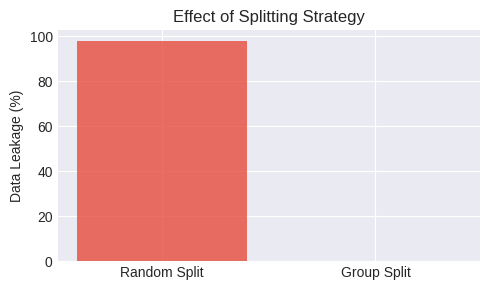

In [ ]:
# Verify no overlap between data splits
train_attempts = set(seq['attempt_id'] for seq in data['train'])
val_attempts = set(seq['attempt_id'] for seq in data['val'])
test_attempts = set(seq['attempt_id'] for seq in data['test'])

overlap_tv = len(train_attempts & val_attempts)
overlap_tt = len(train_attempts & test_attempts)
overlap_vt = len(val_attempts & test_attempts)

print(f"Overlap between splits: {overlap_tv + overlap_tt + overlap_vt} (should be 0)")

# Estimate leakage rate if random splitting were used
seqs_per_attempt = defaultdict(int)
for s in sequences:
    seqs_per_attempt[s['attempt_id']] += 1
multi_seq = sum(1 for c in seqs_per_attempt.values() if c > 1)
potential_leakage = multi_seq / len(seqs_per_attempt) * 100

print(f"Estimated leakage with random split: {potential_leakage:.1f}%")
print(f"Actual leakage with group-based split: 0%")

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(['Random Split', 'Group Split'], [potential_leakage, 0], color=['#e74c3c', '#2ecc71'], alpha=0.8)
ax.set_ylabel('Data Leakage (%)')
ax.set_title('Effect of Splitting Strategy')
plt.tight_layout()
plt.show()

### 3.2 Data Distribution

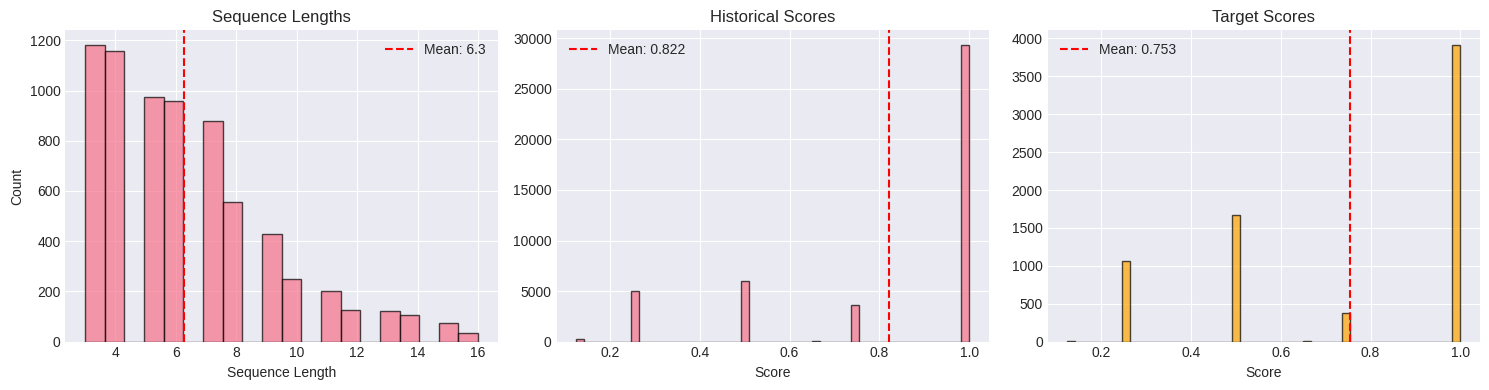

In [ ]:
# Extract scores for visualization
train_scores = np.concatenate([s['history_scores'] for s in data['train']])
train_targets = np.array([s['target_score'] for s in data['train']])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(train_lengths, bins=20, edgecolor='black', alpha=0.7)
axes[0].axvline(np.mean(train_lengths), color='red', linestyle='--', label=f'Mean: {np.mean(train_lengths):.1f}')
axes[0].set_xlabel('Sequence Length')
axes[0].set_ylabel('Count')
axes[0].set_title('Sequence Lengths')
axes[0].legend()

axes[1].hist(train_scores, bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(np.mean(train_scores), color='red', linestyle='--', label=f'Mean: {np.mean(train_scores):.3f}')
axes[1].set_xlabel('Score')
axes[1].set_title('Historical Scores')
axes[1].legend()

axes[2].hist(train_targets, bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[2].axvline(np.mean(train_targets), color='red', linestyle='--', label=f'Mean: {np.mean(train_targets):.3f}')
axes[2].set_xlabel('Score')
axes[2].set_title('Target Scores')
axes[2].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Prepare datasets by extracting features
def prepare_dataset(sequences):
    features_list = []
    targets_list = []
    for seq in tqdm(sequences, desc="Extracting", leave=False):
        features = extract_aggregate_features(seq)
        features_list.append(list(features.values()))
        targets_list.append(seq['target_score'])
    return np.array(features_list), np.array(targets_list)

X_train, y_train = prepare_dataset(data['train'])
X_val, y_val = prepare_dataset(data['val'])
X_test, y_test = prepare_dataset(data['test'])

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# Handle NaN values and normalize
X_train = np.nan_to_num(X_train, nan=0.0, posinf=0.0, neginf=0.0)
X_val = np.nan_to_num(X_val, nan=0.0, posinf=0.0, neginf=0.0)
X_test = np.nan_to_num(X_test, nan=0.0, posinf=0.0, neginf=0.0)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Convert to tensors
X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.FloatTensor(y_train).unsqueeze(1)
X_val_tensor = torch.FloatTensor(X_val_scaled)
y_val_tensor = torch.FloatTensor(y_val).unsqueeze(1)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_test_tensor = torch.FloatTensor(y_test).unsqueeze(1)

Extracting:   0%|          | 0/7047 [00:00<?, ?it/s]

Extracting:   0%|          | 0/826 [00:00<?, ?it/s]

Extracting:   0%|          | 0/946 [00:00<?, ?it/s]

Train: (7047, 26), Val: (826, 26), Test: (946, 26)


## 4. Baseline: MLP with Aggregate Features

We extract 26 features from each sequence and use a multi-layer perceptron for score prediction.

In [ ]:
def extract_aggregate_features(sequence):
    """
    Extract 26 features from a sequence:
    - Statistical (5): mean, std, min, max, last
    - Temporal (2): overall_trend, recent_trend
    - Trajectory (4): consistency, improvement, volatility, length
    - Recent (3): last_3_mean, last_2_mean, momentum
    - Question types (5): frequency of each type
    - Target info (3): type, position, rubric
    - Behavioral (4): fishing_ratio, has_exam_data, log_lag, is_first
    """
    history_scores = np.array(sequence['history_scores'])
    history_types = sequence['history_types']
    features = {}

    # Statistical
    features['mean_score'] = np.mean(history_scores)
    features['std_score'] = np.std(history_scores) if len(history_scores) > 1 else 0
    features['min_score'] = np.min(history_scores)
    features['max_score'] = np.max(history_scores)
    features['last_score'] = history_scores[-1]

    # Temporal
    if len(history_scores) > 1:
        x = np.arange(len(history_scores))
        features['overall_trend'] = np.polyfit(x, history_scores, 1)[0]
    else:
        features['overall_trend'] = 0

    if len(history_scores) >= 3:
        features['recent_trend'] = np.polyfit(np.arange(3), history_scores[-3:], 1)[0]
    else:
        features['recent_trend'] = features['overall_trend']

    # Trajectory
    if features['mean_score'] > 0 and features['std_score'] > 0:
        features['score_consistency'] = 1 / (features['std_score'] / features['mean_score'] + 1e-6)
    else:
        features['score_consistency'] = 0

    features['improvement_rate'] = (history_scores[-1] - history_scores[0]) / len(history_scores) if len(history_scores) > 1 else 0
    features['score_volatility'] = np.std(np.diff(history_scores)) if len(history_scores) > 1 else 0
    features['sequence_length'] = len(history_scores)

    # Recent performance
    features['last_3_mean'] = np.mean(history_scores[-3:]) if len(history_scores) >= 3 else features['mean_score']
    features['last_2_mean'] = np.mean(history_scores[-2:]) if len(history_scores) >= 2 else features['mean_score']

    if len(history_scores) >= 3:
        features['momentum'] = (history_scores[-1] - history_scores[-2]) - (history_scores[-2] - history_scores[-3])
    else:
        features['momentum'] = 0

    # Question type distribution
    for i in range(5):
        features[f'type_{i}_freq'] = history_types.tolist().count(i) / len(history_types) if len(history_types) > 0 else 0

    # Target features
    features['target_type'] = sequence['target_type']
    features['target_position'] = sequence['target_position']
    features['target_rubric_id'] = sequence.get('target_rubric_id', 0)

    # Behavioral features
    features['fishing_ratio'] = sequence['fishing_ratio']
    features['has_exam_data'] = sequence['has_exam_data']
    features['log_inter_attempt_lag'] = sequence['log_inter_attempt_lag']
    features['is_first_attempt'] = sequence['is_first_attempt']

    return features


class MLP(nn.Module):
    """Simple feedforward network: 26 -> 128 -> 64 -> 32 -> 1"""
    def __init__(self, input_dim=26):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)

baseline_model = MLP().to(device)
baseline_params = sum(p.numel() for p in baseline_model.parameters())
print(f"MLP: {baseline_params:,} parameters")

MLP: 13,825 parameters


### 4.1 Train MLP

In [ ]:
# Training loop
optimizer = torch.optim.Adam(baseline_model.parameters(), lr=0.001, weight_decay=0.0001)
criterion = nn.MSELoss()

max_iterations = 500
batch_size = 32
patience = 20
best_val_loss = float('inf')
patience_counter = 0
baseline_history = {'train_rmse': [], 'val_rmse': []}

num_samples = len(X_train_tensor)
num_batches = (num_samples + batch_size - 1) // batch_size

for iteration in range(max_iterations):
    baseline_model.train()
    indices = torch.randperm(num_samples)
    X_shuffled = X_train_tensor[indices]
    y_shuffled = y_train_tensor[indices]

    train_preds, train_targets = [], []
    for i in range(num_batches):
        start, end = i * batch_size, min((i+1) * batch_size, num_samples)
        X_batch = X_shuffled[start:end].to(device)
        y_batch = y_shuffled[start:end].to(device)

        pred = baseline_model(X_batch)
        loss = criterion(pred, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_preds.extend(pred.detach().cpu().numpy())
        train_targets.extend(y_batch.detach().cpu().numpy())

    train_rmse = np.sqrt(mean_squared_error(train_targets, train_preds))

    baseline_model.eval()
    with torch.no_grad():
        val_pred = baseline_model(X_val_tensor.to(device))
        val_loss = criterion(val_pred, y_val_tensor.to(device)).item()
        val_rmse = np.sqrt(mean_squared_error(y_val_tensor.numpy(), val_pred.cpu().numpy()))

    baseline_history['train_rmse'].append(train_rmse)
    baseline_history['val_rmse'].append(val_rmse)

    # Print every 10 iterations
    if (iteration + 1) % 10 == 0:
        marker = " *" if val_loss < best_val_loss else ""
        print(f"Iter {iteration+1}: Train={train_rmse:.4f}, Val={val_rmse:.4f}{marker}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_state = baseline_model.state_dict().copy()
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at {iteration+1}")
            break

baseline_model.load_state_dict(best_state)

Iter 10: Train=0.1331, Val=0.1425 *
Iter 20: Train=0.1305, Val=0.1465
Iter 30: Train=0.1288, Val=0.1407
Iter 40: Train=0.1257, Val=0.1395
Iter 50: Train=0.1244, Val=0.1380
Iter 60: Train=0.1233, Val=0.1393
Iter 70: Train=0.1225, Val=0.1377
Iter 80: Train=0.1211, Val=0.1362
Early stopping at 83


<All keys matched successfully>

### 4.2 Evaluate MLP

In [ ]:
# Test set evaluation
baseline_model.eval()
with torch.no_grad():
    baseline_test_pred = baseline_model(X_test_tensor.to(device)).cpu().numpy()

baseline_test_rmse = np.sqrt(mean_squared_error(y_test, baseline_test_pred))
baseline_test_mae = mean_absolute_error(y_test, baseline_test_pred)
baseline_test_r2 = r2_score(y_test, baseline_test_pred)

print(f"RMSE: {baseline_test_rmse:.4f}, MAE: {baseline_test_mae:.4f}, R²: {baseline_test_r2:.4f}")

RMSE: 0.1275, MAE: 0.0611, R²: 0.8205


---

## 5. LSTM-DKT Model

The LSTM-based Deep Knowledge Tracing model processes sequences directly, learning temporal patterns from the raw interaction data.

In [ ]:
class DKTDataset(Dataset):
    """Dataset for LSTM-DKT with padding and masking."""

    def __init__(self, sequences, max_seq_len=None):
        self.sequences = sequences
        self.max_seq_len = max_seq_len or max(len(s['history_scores']) for s in sequences)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        seq = self.sequences[idx]
        hist_scores = seq['history_scores']
        hist_types = seq['history_types']
        hist_rubrics = seq['history_rubrics']
        seq_len = len(hist_scores)

        # Pad to max_seq_len
        if seq_len < self.max_seq_len:
            pad_len = self.max_seq_len - seq_len
            hist_scores = np.pad(hist_scores, (0, pad_len), constant_values=0)
            hist_types = np.pad(hist_types, (0, pad_len), constant_values=0)
            hist_rubrics = np.pad(hist_rubrics, (0, pad_len), constant_values=0)

        # Mask: 1=real, 0=padding
        mask = np.zeros(self.max_seq_len)
        mask[:seq_len] = 1

        return {
            'scores': torch.FloatTensor(hist_scores),
            'types': torch.LongTensor(hist_types),
            'skills': torch.LongTensor(hist_rubrics),
            'mask': torch.FloatTensor(mask),
            'seq_len': seq_len,
            'target': torch.FloatTensor([seq['target_score']]),
            'fishing_ratio': torch.FloatTensor([seq['fishing_ratio']]),
            'has_exam': torch.FloatTensor([seq['has_exam_data']]),
            'log_lag': torch.FloatTensor([seq['log_inter_attempt_lag']]),
            'is_first': torch.FloatTensor([seq['is_first_attempt']])
        }

In [ ]:
# Create datasets and loaders
dkt_train_dataset = DKTDataset(data['train'])
dkt_val_dataset = DKTDataset(data['val'], max_seq_len=dkt_train_dataset.max_seq_len)
dkt_test_dataset = DKTDataset(data['test'], max_seq_len=dkt_train_dataset.max_seq_len)

dkt_batch_size = 32
dkt_train_loader = DataLoader(dkt_train_dataset, batch_size=dkt_batch_size, shuffle=True)
dkt_val_loader = DataLoader(dkt_val_dataset, batch_size=dkt_batch_size, shuffle=False)
dkt_test_loader = DataLoader(dkt_test_dataset, batch_size=dkt_batch_size, shuffle=False)

print(f"Sequences - Train: {len(dkt_train_dataset)}, Val: {len(dkt_val_dataset)}, Test: {len(dkt_test_dataset)}")

Sequences - Train: 7047, Val: 826, Test: 946


### 5.1 LSTM-DKT Model Architecture

In [ ]:
class LSTM_DKT(nn.Module):
    """
    Bidirectional LSTM for Deep Knowledge Tracing.

    Input per timestep: score(1) + skill_emb(32) + type_emb(16) + fishing(8) + lag(4) = 61 dims
    Output: predicted score for next question
    """

    def __init__(self, num_skills=14, num_types=5, skill_dim=32, type_dim=16,
                 hidden_dim=128, num_layers=2, dropout=0.3):
        super().__init__()

        # Embeddings for categorical features
        self.skill_embedding = nn.Embedding(num_skills, skill_dim)
        self.type_embedding = nn.Embedding(num_types, type_dim)

        # Encoders for behavioral features
        self.fishing_encoder = nn.Linear(2, 8)   # [ratio, has_data] -> 8-dim
        self.lag_encoder = nn.Linear(2, 4)       # [log_lag, is_first] -> 4-dim

        # Bidirectional LSTM
        self.lstm = nn.LSTM(
            input_size=61,  # 1 + 32 + 16 + 8 + 4
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True,
            batch_first=True
        )

        # Prediction head
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )

    def forward(self, scores, types, skills, mask, fishing_ratio, has_exam, log_lag, is_first):
        batch_size, seq_len = scores.shape

        # Embed categorical features
        skill_embs = self.skill_embedding(skills)
        type_embs = self.type_embedding(types)
        scores_expanded = scores.unsqueeze(-1)

        # Encode behavioral features and broadcast across sequence
        fishing_features = torch.cat([fishing_ratio, has_exam], dim=-1)
        fishing_encoded = self.fishing_encoder(fishing_features)
        fishing_expanded = fishing_encoded.unsqueeze(1).repeat(1, seq_len, 1)

        lag_features = torch.cat([log_lag, is_first], dim=-1)
        lag_encoded = self.lag_encoder(lag_features)
        lag_expanded = lag_encoded.unsqueeze(1).repeat(1, seq_len, 1)

        # Concatenate all features (61 dims total)
        x = torch.cat([scores_expanded, skill_embs, type_embs,
                       fishing_expanded, lag_expanded], dim=-1)

        # Pack and run through LSTM
        seq_lengths = mask.sum(dim=1).long()
        packed = nn.utils.rnn.pack_padded_sequence(
            x, seq_lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        packed_out, (h_n, c_n) = self.lstm(packed)

        # Combine forward and backward final hidden states
        h_forward = h_n[-2]
        h_backward = h_n[-1]
        h_final = torch.cat([h_forward, h_backward], dim=1)

        return self.fc(h_final)

# Create model
lstm_model = LSTM_DKT(
    num_skills=14, num_types=5,
    skill_dim=32, type_dim=16,
    hidden_dim=128, num_layers=2, dropout=0.3
).to(device)

lstm_params = sum(p.numel() for p in lstm_model.parameters())
print(f"LSTM-DKT: {lstm_params:,} params")

LSTM-DKT: 609,973 params


### 5.2 Training Functions

In [ ]:
def train_epoch(model, loader, optimizer, criterion, device):
    """Train LSTM-DKT for one epoch."""
    model.train()
    total_loss = 0
    all_preds, all_targets = [], []

    for batch in tqdm(loader, desc="Training", leave=False):
        scores = batch['scores'].to(device)
        types = batch['types'].to(device)
        skills = batch['skills'].to(device)
        mask = batch['mask'].to(device)
        targets = batch['target'].to(device)
        fishing_ratio = batch['fishing_ratio'].to(device)
        has_exam = batch['has_exam'].to(device)
        log_lag = batch['log_lag'].to(device)
        is_first = batch['is_first'].to(device)

        predictions = model(scores, types, skills, mask, fishing_ratio, has_exam, log_lag, is_first)
        loss = criterion(predictions, targets)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        total_loss += loss.item()
        all_preds.extend(predictions.detach().cpu().numpy())
        all_targets.extend(targets.detach().cpu().numpy())

    avg_loss = total_loss / len(loader)
    rmse = np.sqrt(mean_squared_error(all_targets, all_preds))
    return avg_loss, rmse


def evaluate(model, loader, criterion, device):
    """Evaluate LSTM-DKT on a dataset."""
    model.eval()
    total_loss = 0
    all_preds, all_targets = [], []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating", leave=False):
            scores = batch['scores'].to(device)
            types = batch['types'].to(device)
            skills = batch['skills'].to(device)
            mask = batch['mask'].to(device)
            targets = batch['target'].to(device)
            fishing_ratio = batch['fishing_ratio'].to(device)
            has_exam = batch['has_exam'].to(device)
            log_lag = batch['log_lag'].to(device)
            is_first = batch['is_first'].to(device)

            predictions = model(scores, types, skills, mask, fishing_ratio, has_exam, log_lag, is_first)
            loss = criterion(predictions, targets)

            total_loss += loss.item()
            all_preds.extend(predictions.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())

    avg_loss = total_loss / len(loader)
    rmse = np.sqrt(mean_squared_error(all_targets, all_preds))
    mae = mean_absolute_error(all_targets, all_preds)
    r2 = r2_score(all_targets, all_preds)
    return avg_loss, rmse, mae, r2, all_preds, all_targets

### 5.3 Train LSTM-DKT

In [ ]:
# Training loop
lstm_optimizer = torch.optim.Adam(lstm_model.parameters(), lr=0.001, weight_decay=0.0001)
lstm_criterion = nn.MSELoss()

num_epochs = 100
lstm_patience = 20
best_lstm_val_rmse = float('inf')
lstm_patience_counter = 0
lstm_history = {'train_loss': [], 'train_rmse': [], 'val_loss': [], 'val_rmse': []}

for epoch in range(num_epochs):
    train_loss, train_rmse = train_epoch(lstm_model, dkt_train_loader, lstm_optimizer, lstm_criterion, device)
    val_loss, val_rmse, _, _, _, _ = evaluate(lstm_model, dkt_val_loader, lstm_criterion, device)

    lstm_history['train_loss'].append(train_loss)
    lstm_history['train_rmse'].append(train_rmse)
    lstm_history['val_loss'].append(val_loss)
    lstm_history['val_rmse'].append(val_rmse)

    marker = " *" if val_rmse < best_lstm_val_rmse else ""
    print(f"Epoch {epoch+1:3d}: Train={train_rmse:.4f}, Val={val_rmse:.4f}{marker}")

    if val_rmse < best_lstm_val_rmse:
        best_lstm_val_rmse = val_rmse
        lstm_patience_counter = 0
        best_lstm_state = lstm_model.state_dict().copy()
    else:
        lstm_patience_counter += 1
        if lstm_patience_counter >= lstm_patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

lstm_model.load_state_dict(best_lstm_state)

Training:   0%|          | 0/221 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/26 [00:00<?, ?it/s]

Epoch   1: Train=0.3153, Val=0.1642 *


Training:   0%|          | 0/221 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/26 [00:00<?, ?it/s]

...

Epoch  79: Train=0.1585, Val=0.1524


Training:   0%|          | 0/221 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/26 [00:00<?, ?it/s]

Epoch  80: Train=0.1584, Val=0.1537
Early stopping at epoch 80


<All keys matched successfully>

---

## 6. Results & Analysis

### 6.1 Test Set Evaluation

In [ ]:
# Test set evaluation
lstm_test_loss, lstm_test_rmse, lstm_test_mae, lstm_test_r2, lstm_test_preds, lstm_test_targets = \
    evaluate(lstm_model, dkt_test_loader, lstm_criterion, device)

print(f"RMSE: {lstm_test_rmse:.4f}, MAE: {lstm_test_mae:.4f}, R²: {lstm_test_r2:.4f}")

Evaluating:   0%|          | 0/30 [00:00<?, ?it/s]

RMSE: 0.1458, MAE: 0.0939, R²: 0.7653


### 6.2 Model Comparison

In [ ]:
# Model comparison
rmse_diff = (lstm_test_rmse - baseline_test_rmse) / baseline_test_rmse * 100

print(f"MLP:      RMSE = {baseline_test_rmse:.4f}, R² = {baseline_test_r2:.4f}")
print(f"LSTM-DKT: RMSE = {lstm_test_rmse:.4f}, R² = {lstm_test_r2:.4f}")
print(f"")
print(f"The MLP demonstrates {abs(rmse_diff):.1f}% lower RMSE compared to LSTM-DKT.")
print(f"This aligns with prior work showing that feature engineering")
print(f"tends to outperform deep learning on smaller structured datasets.")

MLP:      RMSE = 0.1275, R² = 0.8205
LSTM-DKT: RMSE = 0.1458, R² = 0.7653

The MLP demonstrates 14.3% lower RMSE compared to LSTM-DKT.
This aligns with prior work showing that feature engineering
tends to outperform deep learning on smaller structured datasets.


### 6.3 Analysis: Model Capacity vs. Data Size

The performance difference can be attributed to the parameter-to-sample ratio.

Training samples: 7,047
MLP:      0.51 samples per parameter
LSTM-DKT: 0.0116 samples per parameter

The LSTM-DKT model has approximately 2x fewer
samples per parameter than typically recommended (10+ samples/parameter).


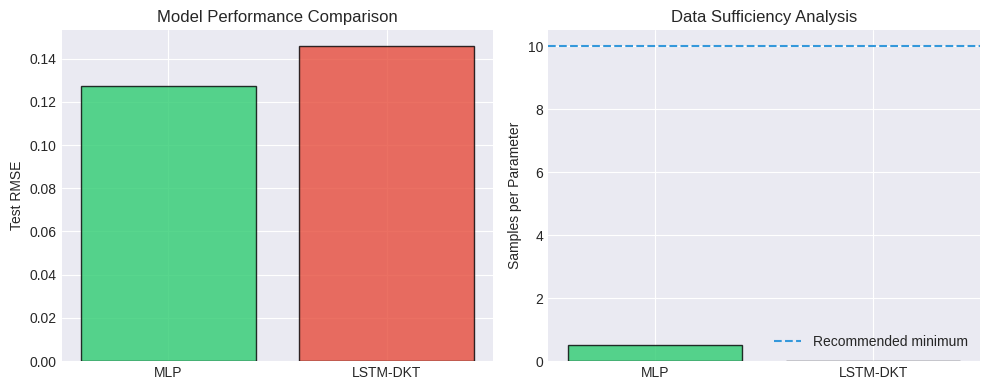

In [ ]:
# Analysis: Parameter-to-sample ratio
train_samples = len(data['train'])
mlp_ratio = train_samples / baseline_params
lstm_ratio = train_samples / lstm_params

print(f"Training samples: {train_samples:,}")
print(f"MLP:      {mlp_ratio:.2f} samples per parameter")
print(f"LSTM-DKT: {lstm_ratio:.4f} samples per parameter")
print(f"")
print(f"The LSTM-DKT model has approximately {baseline_params/lstm_params*100:.0f}x fewer")
print(f"samples per parameter than typically recommended (10+ samples/parameter).")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(['MLP', 'LSTM-DKT'], [baseline_test_rmse, lstm_test_rmse],
            color=['#2ecc71', '#e74c3c'], alpha=0.8, edgecolor='black')
axes[0].set_ylabel('Test RMSE')
axes[0].set_title('Model Performance Comparison')

axes[1].bar(['MLP', 'LSTM-DKT'], [mlp_ratio, lstm_ratio],
            color=['#2ecc71', '#e74c3c'], alpha=0.8, edgecolor='black')
axes[1].axhline(10, color='#3498db', linestyle='--', label='Recommended minimum')
axes[1].set_ylabel('Samples per Parameter')
axes[1].set_title('Data Sufficiency Analysis')
axes[1].legend()

plt.tight_layout()
plt.show()

### 6.4 Visualizations

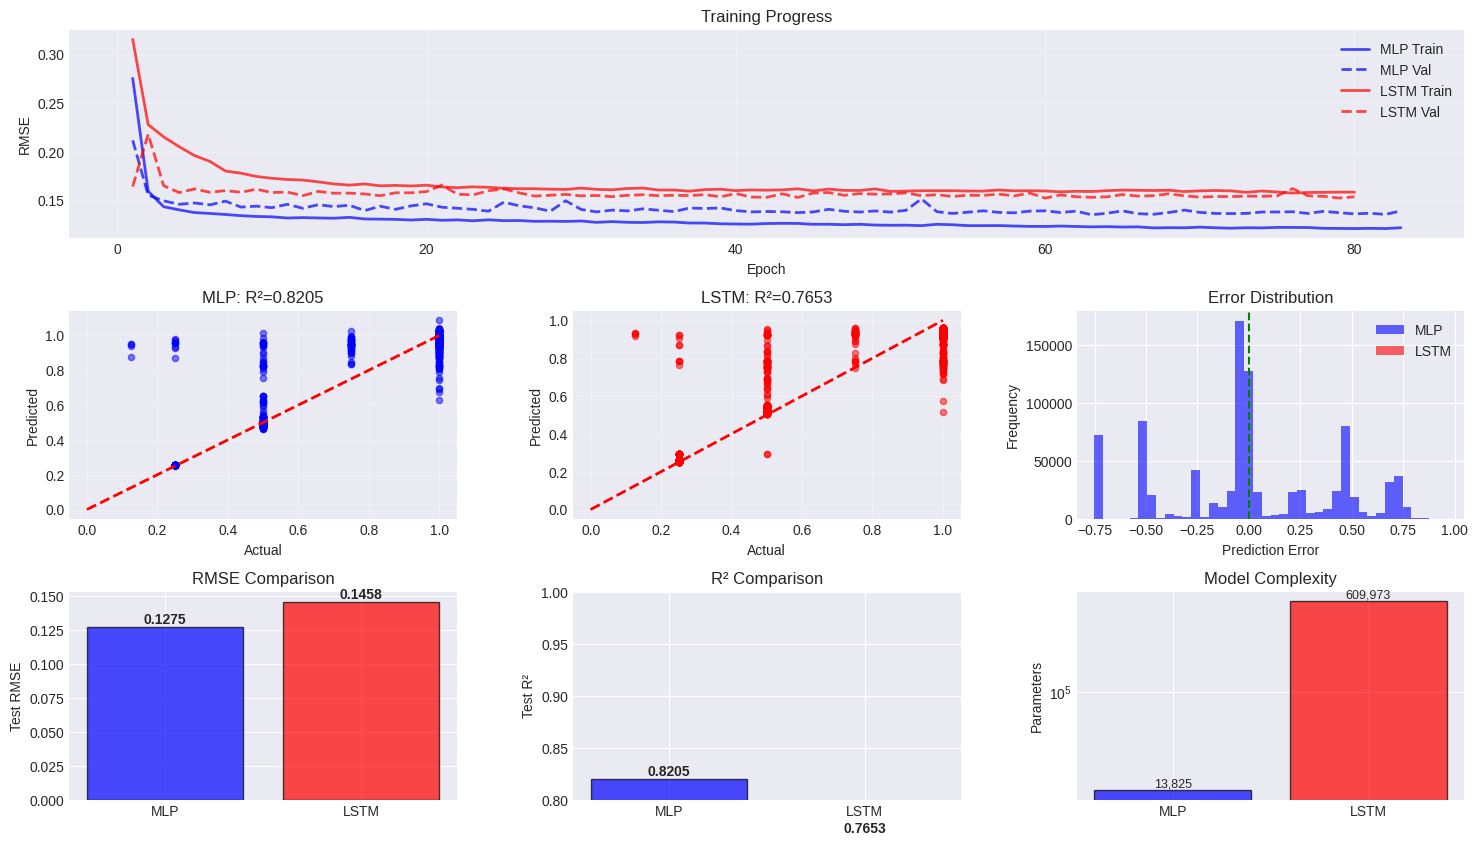

In [ ]:
# Comprehensive comparison visualization
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# Training curves
ax1 = fig.add_subplot(gs[0, :])
epochs_mlp = range(1, len(baseline_history['train_rmse']) + 1)
epochs_lstm = range(1, len(lstm_history['train_rmse']) + 1)
ax1.plot(epochs_mlp, baseline_history['train_rmse'], 'b-', linewidth=2, label='MLP Train', alpha=0.7)
ax1.plot(epochs_mlp, baseline_history['val_rmse'], 'b--', linewidth=2, label='MLP Val', alpha=0.7)
ax1.plot(epochs_lstm, lstm_history['train_rmse'], 'r-', linewidth=2, label='LSTM Train', alpha=0.7)
ax1.plot(epochs_lstm, lstm_history['val_rmse'], 'r--', linewidth=2, label='LSTM Val', alpha=0.7)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('RMSE')
ax1.set_title('Training Progress')
ax1.legend(loc='upper right')
ax1.grid(alpha=0.3)

# Actual vs Predicted - MLP
ax2 = fig.add_subplot(gs[1, 0])
ax2.scatter(y_test, baseline_test_pred, alpha=0.5, s=20, c='blue')
ax2.plot([0, 1], [0, 1], 'r--', linewidth=2)
ax2.set_xlabel('Actual')
ax2.set_ylabel('Predicted')
ax2.set_title(f'MLP: R²={baseline_test_r2:.4f}')
ax2.grid(alpha=0.3)

# Actual vs Predicted - LSTM
ax3 = fig.add_subplot(gs[1, 1])
ax3.scatter(lstm_test_targets, lstm_test_preds, alpha=0.5, s=20, c='red')
ax3.plot([0, 1], [0, 1], 'r--', linewidth=2)
ax3.set_xlabel('Actual')
ax3.set_ylabel('Predicted')
ax3.set_title(f'LSTM: R²={lstm_test_r2:.4f}')
ax3.grid(alpha=0.3)

# Error distributions
ax4 = fig.add_subplot(gs[1, 2])
mlp_errors = (baseline_test_pred - y_test).flatten()
lstm_errors = (np.array(lstm_test_preds) - np.array(lstm_test_targets)).flatten()
ax4.hist(mlp_errors, bins=40, alpha=0.6, label='MLP', color='blue')
ax4.hist(lstm_errors, bins=40, alpha=0.6, label='LSTM', color='red')
ax4.axvline(x=0, color='green', linestyle='--')
ax4.set_xlabel('Prediction Error')
ax4.set_ylabel('Frequency')
ax4.set_title('Error Distribution')
ax4.legend()

# RMSE comparison
ax5 = fig.add_subplot(gs[2, 0])
models = ['MLP', 'LSTM']
rmses = [baseline_test_rmse, lstm_test_rmse]
colors = ['blue', 'red']
bars = ax5.bar(models, rmses, color=colors, alpha=0.7, edgecolor='black')
ax5.set_ylabel('Test RMSE')
ax5.set_title('RMSE Comparison')
for bar, rmse in zip(bars, rmses):
    ax5.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
             f'{rmse:.4f}', ha='center', va='bottom', fontweight='bold')

# R² comparison
ax6 = fig.add_subplot(gs[2, 1])
r2s = [baseline_test_r2, lstm_test_r2]
bars = ax6.bar(models, r2s, color=colors, alpha=0.7, edgecolor='black')
ax6.set_ylabel('Test R²')
ax6.set_title('R² Comparison')
ax6.set_ylim([0.8, 1.0])
for bar, r2 in zip(bars, r2s):
    ax6.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
             f'{r2:.4f}', ha='center', va='bottom', fontweight='bold')

# Parameters comparison
ax7 = fig.add_subplot(gs[2, 2])
params = [baseline_params, lstm_params]
bars = ax7.bar(models, params, color=colors, alpha=0.7, edgecolor='black')
ax7.set_ylabel('Parameters')
ax7.set_yscale('log')
ax7.set_title('Model Complexity')
for bar, param in zip(bars, params):
    ax7.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
             f'{param:,}', ha='center', va='bottom', fontsize=9)

plt.show()

---

## 7. Conclusions

This project compared feature-based and sequence-based approaches for knowledge tracing in medical education.